# A/B Test Analysis — Firmware 6.4.2 → 6.5.0 Update

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, mannwhitneyu

# Dark theme rcParams
plt.rcParams.update({
    'figure.facecolor': '#1a1a2e',
    'axes.facecolor': '#16213e',
    'axes.edgecolor': 'white',
    'axes.labelcolor': 'white',
    'text.color': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'grid.color': '#0f3460',
    'grid.alpha': 0.3,
    'legend.facecolor': '#16213e',
    'legend.edgecolor': 'white',
    'legend.labelcolor': 'white',
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.facecolor': '#1a1a2e',
    'font.size': 12
})

# Load datasets
firmware = pd.read_csv('../data/firmware_updates.csv', parse_dates=['update_date'])
network = pd.read_csv('../data/network_events.csv', parse_dates=['date'])
sessions = pd.read_csv('../data/user_sessions.csv', parse_dates=['date'])

print(f"Firmware updates: {len(firmware)} rows")
print(f"Network events:   {len(network)} rows")
print(f"User sessions:    {len(sessions)} rows")
print()
print("Firmware update combinations:")
print(firmware.groupby(['old_firmware', 'new_firmware', 'update_success']).size().reset_index(name='count').to_string(index=False))

/Users/harthikmallichetty/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Firmware updates: 2351 rows
Network events:   450000 rows
User sessions:    373313 rows

Firmware update combinations:
old_firmware new_firmware  update_success  count
       6.4.0        6.4.0               0    548
       6.4.0        6.5.0               1    630
       6.4.2        6.4.2               0    536
       6.4.2        6.5.0               1    637


## Define Control and Treatment Groups

In [2]:
# Treatment: households that successfully updated from 6.4.2 to 6.5.0
treatment = firmware[
    (firmware['old_firmware'] == '6.4.2') &
    (firmware['new_firmware'] == '6.5.0') &
    (firmware['update_success'] == 1)
].copy()

# Control: households that stayed on 6.4.2 (didn't update or update failed)
control = firmware[
    (firmware['old_firmware'] == '6.4.2') &
    ((firmware['new_firmware'] == '6.4.2') | (firmware['update_success'] == 0))
].copy()

# Remove any overlap — if a household appears in both, keep only control entry
control = control[~control['household_id'].isin(treatment['household_id'])]

print(f"Treatment group (6.4.2 → 6.5.0, success): {len(treatment)} households")
print(f"Control group   (stayed on 6.4.2):         {len(control)} households")
print(f"\nTreatment update dates: {treatment['update_date'].min().date()} to {treatment['update_date'].max().date()}")
print(f"Control update dates:   {control['update_date'].min().date()} to {control['update_date'].max().date()}")

Treatment group (6.4.2 → 6.5.0, success): 637 households
Control group   (stayed on 6.4.2):         536 households

Treatment update dates: 2024-01-31 to 2024-05-29
Control update dates:   2024-01-31 to 2024-05-29


## Primary Metric: Connection Drops

In [3]:
# Descriptive statistics
t_drops = treatment['post_update_drops_7day']
c_drops = control['post_update_drops_7day']

print("=" * 60)
print("PRIMARY METRIC: Post-Update Connection Drops (7-day window)")
print("=" * 60)
print(f"{'Metric':<25} {'Control':>12} {'Treatment':>12}")
print("-" * 50)
print(f"{'N':<25} {len(c_drops):>12} {len(t_drops):>12}")
print(f"{'Mean':<25} {c_drops.mean():>12.3f} {t_drops.mean():>12.3f}")
print(f"{'Median':<25} {c_drops.median():>12.1f} {t_drops.median():>12.1f}")
print(f"{'Std Dev':<25} {c_drops.std():>12.3f} {t_drops.std():>12.3f}")
print()

# Two-sample t-test (independent, two-sided)
t_stat, t_pvalue = ttest_ind(c_drops, t_drops, equal_var=False)
print(f"Welch's t-test:     t = {t_stat:.4f}, p = {t_pvalue:.6f}")

# Mann-Whitney U test (non-parametric)
u_stat, u_pvalue = mannwhitneyu(c_drops, t_drops, alternative='two-sided')
print(f"Mann-Whitney U test: U = {u_stat:.1f},  p = {u_pvalue:.6f}")
print()

# Lift calculation
lift = (c_drops.mean() - t_drops.mean()) / c_drops.mean() * 100
print(f"Lift (reduction in drops): {lift:.2f}%")

# 95% confidence interval for difference in means
diff_mean = c_drops.mean() - t_drops.mean()
se_diff = np.sqrt(c_drops.var() / len(c_drops) + t_drops.var() / len(t_drops))
ci_lower = diff_mean - 1.96 * se_diff
ci_upper = diff_mean + 1.96 * se_diff
print(f"Difference in means: {diff_mean:.3f}")
print(f"95% CI for difference: [{ci_lower:.3f}, {ci_upper:.3f}]")
print()
print(f"Statistically significant (p < 0.05)? {'YES' if t_pvalue < 0.05 else 'NO'}")

PRIMARY METRIC: Post-Update Connection Drops (7-day window)
Metric                         Control    Treatment
--------------------------------------------------
N                                  536          637
Mean                             4.009        2.724
Median                             4.0          3.0
Std Dev                          2.015        1.643

Welch's t-test:     t = 11.8268, p = 0.000000
Mann-Whitney U test: U = 234264.0,  p = 0.000000

Lift (reduction in drops): 32.07%
Difference in means: 1.286
95% CI for difference: [1.073, 1.499]

Statistically significant (p < 0.05)? YES


## Secondary Metrics

In [4]:
# For each household, compute post-update avg latency and total support tickets

def compute_post_update_metrics(group_df, network_df, sessions_df):
    """Compute post-update metrics for a group of households."""
    records = []
    for _, row in group_df.iterrows():
        hid = row['household_id']
        udate = row['update_date']

        # Post-update network events
        net_post = network_df[
            (network_df['household_id'] == hid) &
            (network_df['date'] > udate)
        ]
        avg_latency = net_post['avg_latency_ms'].mean() if len(net_post) > 0 else np.nan

        # Post-update support tickets
        sess_post = sessions_df[
            (sessions_df['household_id'] == hid) &
            (sessions_df['date'] > udate)
        ]
        total_tickets = sess_post['support_ticket_raised'].sum() if len(sess_post) > 0 else 0

        records.append({
            'household_id': hid,
            'avg_latency_ms': avg_latency,
            'total_support_tickets': total_tickets
        })
    return pd.DataFrame(records)

treatment_metrics = compute_post_update_metrics(treatment, network, sessions)
control_metrics = compute_post_update_metrics(control, network, sessions)

# T-tests for secondary metrics
results = []

for metric, label in [('avg_latency_ms', 'Avg Latency (ms)'), ('total_support_tickets', 'Total Support Tickets')]:
    t_vals = treatment_metrics[metric].dropna()
    c_vals = control_metrics[metric].dropna()
    t_stat, p_val = ttest_ind(c_vals, t_vals, equal_var=False)
    results.append({
        'Metric': label,
        'Control Mean': f"{c_vals.mean():.3f}",
        'Treatment Mean': f"{t_vals.mean():.3f}",
        'Difference': f"{c_vals.mean() - t_vals.mean():.3f}",
        't-statistic': f"{t_stat:.4f}",
        'p-value': f"{p_val:.6f}",
        'Significant': 'Yes' if p_val < 0.05 else 'No'
    })

results_df = pd.DataFrame(results)
print("=" * 70)
print("SECONDARY METRICS: Post-Update Comparison")
print("=" * 70)
print(results_df.to_string(index=False))

SECONDARY METRICS: Post-Update Comparison
               Metric Control Mean Treatment Mean Difference t-statistic  p-value Significant
     Avg Latency (ms)       27.260         26.921      0.339      0.8551 0.392670          No
Total Support Tickets        1.011          1.094     -0.083     -1.1369 0.255819          No


## Visualization

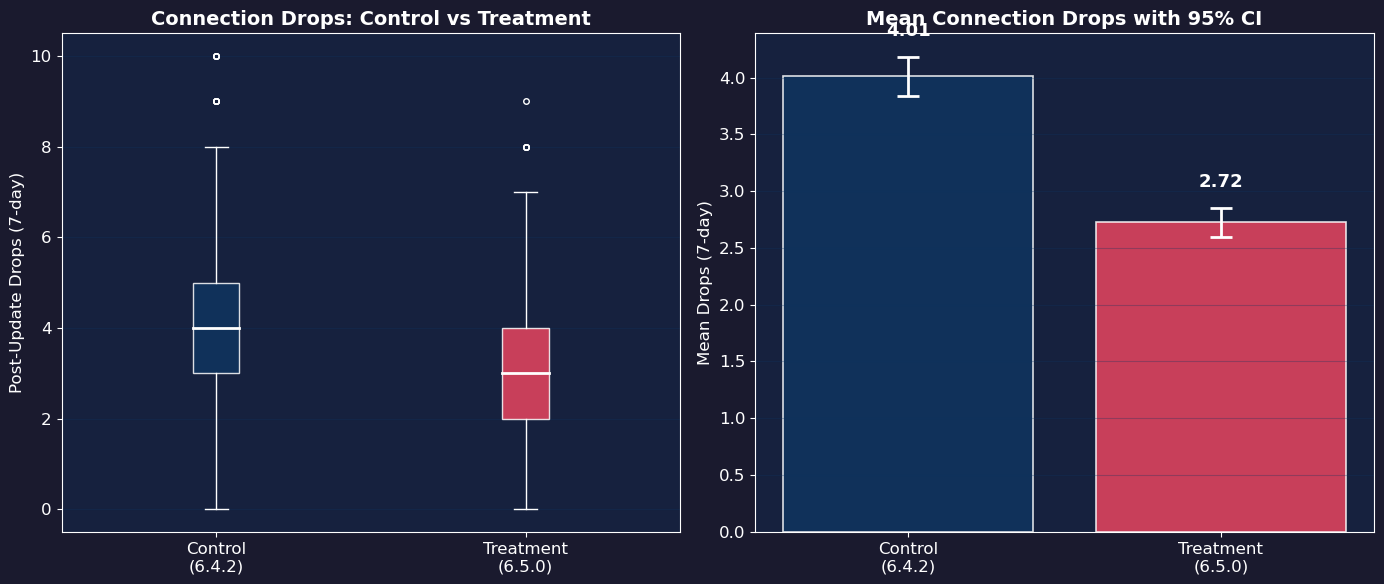

Saved: ../images/ab_test_results.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Subplot 1: Box plot ---
ax1 = axes[0]
box_data = pd.DataFrame({
    'Group': ['Control'] * len(c_drops) + ['Treatment'] * len(t_drops),
    'Post-Update Drops (7-day)': pd.concat([c_drops, t_drops], ignore_index=True)
})
bp = ax1.boxplot(
    [c_drops.values, t_drops.values],
    labels=['Control\n(6.4.2)', 'Treatment\n(6.5.0)'],
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color='white'),
    capprops=dict(color='white'),
    flierprops=dict(markeredgecolor='white', marker='o', markersize=4)
)
colors_box = ['#0f3460', '#e94560']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_edgecolor('white')
    patch.set_alpha(0.85)
ax1.set_title('Connection Drops: Control vs Treatment', fontsize=14, fontweight='bold')
ax1.set_ylabel('Post-Update Drops (7-day)', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

# --- Subplot 2: Bar chart with 95% CI error bars ---
ax2 = axes[1]
means = [c_drops.mean(), t_drops.mean()]
# 95% CI = 1.96 * SE
ci_errors = [
    1.96 * c_drops.std() / np.sqrt(len(c_drops)),
    1.96 * t_drops.std() / np.sqrt(len(t_drops))
]
bar_colors = ['#0f3460', '#e94560']
bars = ax2.bar(
    ['Control\n(6.4.2)', 'Treatment\n(6.5.0)'],
    means,
    yerr=ci_errors,
    capsize=8,
    color=bar_colors,
    edgecolor='white',
    linewidth=1.2,
    alpha=0.85,
    error_kw={'ecolor': 'white', 'elinewidth': 2, 'capthick': 2}
)
# Add value labels on bars
for bar, mean, ci in zip(bars, means, ci_errors):
    ax2.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + ci + 0.15,
        f'{mean:.2f}', ha='center', va='bottom', fontsize=13, fontweight='bold', color='white'
    )
ax2.set_title('Mean Connection Drops with 95% CI', fontsize=14, fontweight='bold')
ax2.set_ylabel('Mean Drops (7-day)', fontsize=12)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/ab_test_results.png', dpi=300, facecolor='#1a1a2e', bbox_inches='tight')
plt.show()
print("Saved: ../images/ab_test_results.png")

## Pre/Post Comparison

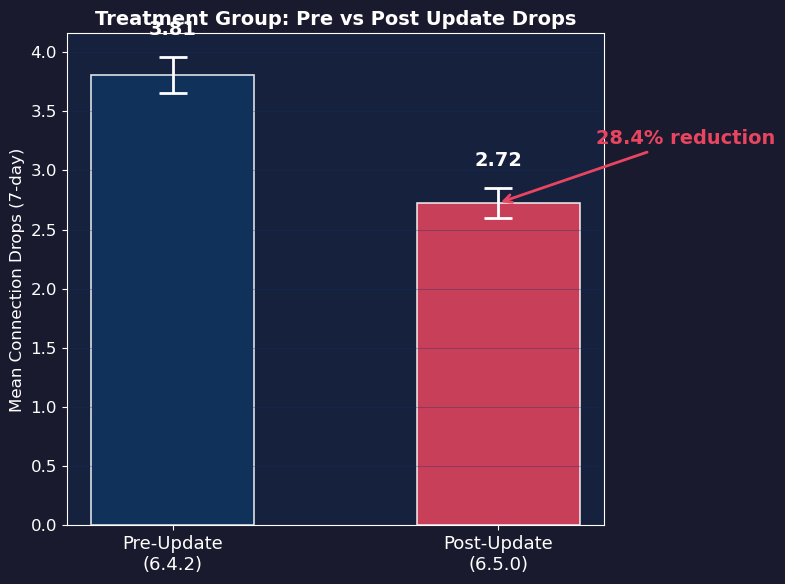


Pre-update mean:  3.805
Post-update mean: 2.724
Reduction:        1.082 drops (28.4%)

Saved: ../images/ab_test_pre_post.png


In [6]:
# Pre vs Post drops for the treatment group
pre_mean = treatment['pre_update_drops_7day'].mean()
post_mean = treatment['post_update_drops_7day'].mean()
pre_ci = 1.96 * treatment['pre_update_drops_7day'].std() / np.sqrt(len(treatment))
post_ci = 1.96 * treatment['post_update_drops_7day'].std() / np.sqrt(len(treatment))
reduction = pre_mean - post_mean
reduction_pct = reduction / pre_mean * 100

fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(2)
bar_colors = ['#0f3460', '#e94560']
bars = ax.bar(
    x, [pre_mean, post_mean],
    yerr=[pre_ci, post_ci],
    capsize=10,
    color=bar_colors,
    edgecolor='white',
    linewidth=1.2,
    alpha=0.85,
    width=0.5,
    error_kw={'ecolor': 'white', 'elinewidth': 2, 'capthick': 2}
)
ax.set_xticks(x)
ax.set_xticklabels(['Pre-Update\n(6.4.2)', 'Post-Update\n(6.5.0)'], fontsize=13)
ax.set_ylabel('Mean Connection Drops (7-day)', fontsize=12)
ax.set_title('Treatment Group: Pre vs Post Update Drops', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar, mean, ci in zip(bars, [pre_mean, post_mean], [pre_ci, post_ci]):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + ci + 0.15,
        f'{mean:.2f}', ha='center', va='bottom', fontsize=14, fontweight='bold', color='white'
    )

# Add annotation for reduction
ax.annotate(
    f'{reduction_pct:.1f}% reduction',
    xy=(1, post_mean), xytext=(1.3, (pre_mean + post_mean) / 2),
    fontsize=14, fontweight='bold', color='#e94560',
    arrowprops=dict(arrowstyle='->', color='#e94560', lw=2),
    ha='left', va='center'
)

plt.tight_layout()
plt.savefig('../images/ab_test_pre_post.png', dpi=300, facecolor='#1a1a2e', bbox_inches='tight')
plt.show()
print(f"\nPre-update mean:  {pre_mean:.3f}")
print(f"Post-update mean: {post_mean:.3f}")
print(f"Reduction:        {reduction:.3f} drops ({reduction_pct:.1f}%)")
print(f"\nSaved: ../images/ab_test_pre_post.png")

## Statistical Conclusion

In [7]:
# Recompute key values for the conclusion
t_stat_final, p_value_final = ttest_ind(c_drops, t_drops, equal_var=False)
lift_final = (c_drops.mean() - t_drops.mean()) / c_drops.mean() * 100
diff_final = c_drops.mean() - t_drops.mean()
se_final = np.sqrt(c_drops.var() / len(c_drops) + t_drops.var() / len(t_drops))
ci_low = diff_final - 1.96 * se_final
ci_high = diff_final + 1.96 * se_final
significant = p_value_final < 0.05

print("=" * 65)
print("          A/B TEST CONCLUSION: Firmware 6.4.2 -> 6.5.0")
print("=" * 65)
print()
print(f"  Sample Sizes:")
print(f"    Control (6.4.2):   {len(control)} households")
print(f"    Treatment (6.5.0): {len(treatment)} households")
print()
print(f"  Primary Metric — Post-Update Connection Drops (7-day):")
print(f"    Control mean:   {c_drops.mean():.3f}")
print(f"    Treatment mean: {t_drops.mean():.3f}")
print()
print(f"  Statistical Significance:")
print(f"    p-value:  {p_value_final:.6f}")
print(f"    Result:   {'STATISTICALLY SIGNIFICANT (p < 0.05)' if significant else 'NOT statistically significant (p >= 0.05)'}")
print()
print(f"  Effect Size:")
print(f"    Observed lift:      {lift_final:.2f}% reduction in connection drops")
print(f"    Difference:         {diff_final:.3f} fewer drops")
print(f"    95% CI:             [{ci_low:.3f}, {ci_high:.3f}]")
print()
print("  " + "-" * 61)
print("  RECOMMENDATION:")
print("  " + "-" * 61)
if significant and lift_final > 0:
    print("  The firmware update from 6.4.2 to 6.5.0 shows a statistically")
    print(f"  significant reduction in connection drops ({lift_final:.1f}% improvement).")
    print(f"  The 95% confidence interval [{ci_low:.3f}, {ci_high:.3f}] does not")
    print("  include zero, confirming the positive effect.")
    print()
    print("  >>> RECOMMEND: Roll out firmware 6.5.0 to all 6.4.2 households.")
elif significant and lift_final <= 0:
    print("  The firmware update shows a statistically significant INCREASE")
    print("  in connection drops. The update appears to degrade performance.")
    print()
    print("  >>> RECOMMEND: Do NOT roll out. Investigate regression.")
else:
    print("  The firmware update does not show a statistically significant")
    print("  difference in connection drops between groups.")
    print()
    print("  >>> RECOMMEND: Gather more data or investigate other metrics.")
print("=" * 65)

          A/B TEST CONCLUSION: Firmware 6.4.2 -> 6.5.0

  Sample Sizes:
    Control (6.4.2):   536 households
    Treatment (6.5.0): 637 households

  Primary Metric — Post-Update Connection Drops (7-day):
    Control mean:   4.009
    Treatment mean: 2.724

  Statistical Significance:
    p-value:  0.000000
    Result:   STATISTICALLY SIGNIFICANT (p < 0.05)

  Effect Size:
    Observed lift:      32.07% reduction in connection drops
    Difference:         1.286 fewer drops
    95% CI:             [1.073, 1.499]

  -------------------------------------------------------------
  RECOMMENDATION:
  -------------------------------------------------------------
  The firmware update from 6.4.2 to 6.5.0 shows a statistically
  significant reduction in connection drops (32.1% improvement).
  The 95% confidence interval [1.073, 1.499] does not
  include zero, confirming the positive effect.

  >>> RECOMMEND: Roll out firmware 6.5.0 to all 6.4.2 households.
